# Screener latency vs ping_dual

Дизайн: [`docs/latency-screener-vs-ping-experiment.md`](../docs/latency-screener-vs-ping-experiment.md).

**Lean derive (latency не в parquet):**

```text
okx_latency_ms   = okx_local_recv_ts_ms   - okx_ts_ms
bybit_latency_ms = bybit_local_recv_ts_ms - bybit_ts_ms
```

Сравнивать только **trigger-leg** на matched XRP (оба ping на одной монете):
- ping OKX = `XRP-USDT-SWAP` → screener `base_coin=XRP`, `trigger==okx`
- ping Bybit = `XRPUSDT` → screener `base_coin=XRP`, `trigger==bybit`

Локальные копии (после download с VPS):
- ping: `output/ping_dual_6h_xrp.log`
- lean XRP (из compacted backup, окно ~13:00–19:00 UTC): `output/latency_exp_xrp_live/`

На VPS active `/data/live/base_coin=XRP/event_date=2026-08-05/` пуст (архив только ~23:15+); для overlap с ping использованы `backup1tb:spread-compacted` 5-min windows.

In [1]:
from __future__ import annotations

from pathlib import Path
import re
from datetime import datetime, timezone

import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
if not (ROOT / "output" / "ping_dual_6h_xrp.log").exists():
    ROOT = Path.cwd()
    if not (ROOT / "output" / "ping_dual_6h_xrp.log").exists():
        ROOT = Path("/Users/mishatrubik/Desktop/spread")

# --- configure (local experiment copies) ---
LIVE_ROOT = ROOT / "output" / "latency_exp_xrp_live"
PING_LOG = ROOT / "output" / "ping_dual_6h_xrp.log"
OUT_DIR = ROOT / "output"
EVENT_DATES = ["2026-08-05"]
COMPARE_COIN = "XRP"
SPIKE_MS = 500
DUAL_SPIKE_MS = 1000

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("ROOT", ROOT)
print("LIVE_ROOT", LIVE_ROOT, "exists", LIVE_ROOT.exists())
print("PING_LOG", PING_LOG, "exists", PING_LOG.exists(), "size", PING_LOG.stat().st_size if PING_LOG.exists() else None)

ROOT /Users/mishatrubik/Desktop/spread
LIVE_ROOT /Users/mishatrubik/Desktop/spread/output/latency_exp_xrp_live exists True
PING_LOG /Users/mishatrubik/Desktop/spread/output/ping_dual_6h_xrp.log exists True size 37921812


## 1. Ping log → DataFrame

In [2]:
ts_re = re.compile(r"^(\d{4}-\d{2}-\d{2}T[^\t]+)\t(okx|bybit)\t(.*)$")
kv_re = re.compile(r"(\w+)=([^\t]+)")
meta_re = re.compile(r"^(\d{4}-\d{2}-\d{2}T[^\t]+)\tmeta\t(.*)$")


def _to_float(v):
    if v in (None, "None", ""):
        return None
    try:
        return float(v)
    except ValueError:
        return None


def load_ping_meta(path: Path) -> dict:
    meta = {}
    with path.open() as f:
        for line in f:
            m = meta_re.match(line.rstrip("\n"))
            if not m:
                continue
            ts_s, rest = m.groups()
            kvs = dict(kv_re.findall(rest))
            ev = kvs.get("event")
            if ev in ("start", "finished"):
                meta[ev] = {"ts": ts_s, **kvs}
            if ev == "finished":
                break
    return meta


def load_ping_log(path: Path) -> pd.DataFrame:
    rows = []
    with path.open() as f:
        for line in f:
            line = line.rstrip("\n")
            m = ts_re.match(line)
            if not m:
                continue
            ts_s, exch, rest = m.groups()
            kvs = dict(kv_re.findall(rest))
            if "latency_ms" not in kvs:
                continue
            rows.append(
                {
                    "timestamp": datetime.fromisoformat(ts_s.replace("Z", "+00:00")),
                    "exchange": exch,
                    "latency_ms": float(kvs["latency_ms"]),
                    "age_ts_ms": _to_float(kvs.get("age_ts_ms")),
                    "age_cts_ms": _to_float(kvs.get("age_cts_ms")),
                }
            )
    df = pd.DataFrame(rows)
    if not df.empty:
        df["minute"] = df["timestamp"].dt.floor("min")
    return df


ping_meta = load_ping_meta(PING_LOG)
print("ping meta start:", ping_meta.get("start"))
print("ping meta finished:", ping_meta.get("finished"))

df_ping = load_ping_log(PING_LOG)
print("ping rows", len(df_ping))
if not df_ping.empty:
    print(df_ping["exchange"].value_counts().to_string())
    print("window", df_ping["timestamp"].min(), "→", df_ping["timestamp"].max())
df_ping.head()

ping meta start: {'ts': '2026-08-05T13:00:27.404Z', 'event': 'start', 'duration_sec': '21600.0', 'log': '/var/log/spread/ping_dual_6h_xrp.log', 'okx_inst': 'XRP-USDT-SWAP', 'bybit_symbol': 'XRPUSDT'}
ping meta finished: {'ts': '2026-08-05T19:00:28.559Z', 'event': 'finished', 'okx_samples': '146997', 'bybit_samples': '256801', 'okx_inst': 'XRP-USDT-SWAP', 'bybit_symbol': 'XRPUSDT'}
ping rows 403798
exchange
bybit    256801
okx      146997
window 2026-08-05 13:00:27.674000+00:00 → 2026-08-05 19:00:27.335000+00:00


,timestamp,exchange,latency_ms,age_ts_ms,age_cts_ms,minute
0,2026-08-05 13:00:27.674000+00:00,bybit,143.0,143.0,145.0,2026-08-05 13:00:00+00:00
1,2026-08-05 13:00:27.708000+00:00,bybit,17.0,17.0,24.0,2026-08-05 13:00:00+00:00
2,2026-08-05 13:00:27.717000+00:00,bybit,16.0,16.0,25.0,2026-08-05 13:00:00+00:00
3,2026-08-05 13:00:27.728000+00:00,bybit,17.0,17.0,19.0,2026-08-05 13:00:00+00:00
4,2026-08-05 13:00:27.879000+00:00,bybit,17.0,17.0,20.0,2026-08-05 13:00:00+00:00


## 2. Lean ticks → derive latency (XRP matched)

In [3]:
LEAN_COLS = [
    "event_local_ts_ms",
    "base_coin",
    "trigger",
    "calc_local_ts_ms",
    "okx_local_recv_ts_ms",
    "okx_ts_ms",
    "bybit_local_recv_ts_ms",
    "bybit_ts_ms",
]


def list_lean_files(root: Path, coin: str, event_dates):
    if event_dates:
        paths = []
        for d in event_dates:
            paths.extend(sorted((root / f"base_coin={coin}" / f"event_date={d}").glob("batch_*.parquet")))
        return paths
    return sorted((root / f"base_coin={coin}").glob("event_date=*/batch_*.parquet"))


def _read_lean_table(path: Path):
    # ParquetFile avoids hive-partition merge conflicts when path contains base_coin=
    available = set(pq.ParquetFile(path).schema_arrow.names)
    cols = [c for c in LEAN_COLS if c in available]
    return pq.ParquetFile(path).read(columns=cols)


def load_lean_coin(root: Path, coin: str, event_dates=None) -> pd.DataFrame:
    files = list_lean_files(root, coin, event_dates)
    if not files:
        print(f"WARN: no parquet for {coin} under {root}")
        return pd.DataFrame()
    tables = [_read_lean_table(p) for p in files]
    df = pd.concat([t.to_pandas() for t in tables], ignore_index=True)
    df["okx_latency_ms"] = df["okx_local_recv_ts_ms"] - df["okx_ts_ms"]
    df["bybit_latency_ms"] = df["bybit_local_recv_ts_ms"] - df["bybit_ts_ms"]
    df["trigger_latency_ms"] = df["okx_latency_ms"].where(
        df["trigger"].eq("okx"), df["bybit_latency_ms"]
    )
    # freshness = cost after trigger recv stamp (not event_local)
    trigger_recv = df["okx_local_recv_ts_ms"].where(
        df["trigger"].eq("okx"), df["bybit_local_recv_ts_ms"]
    )
    df["trigger_freshness_ms"] = df["calc_local_ts_ms"] - trigger_recv
    df["timestamp"] = pd.to_datetime(df["event_local_ts_ms"], unit="ms", utc=True)
    df["minute"] = df["timestamp"].dt.floor("min")
    df["base_coin"] = coin
    print(f"{coin}: files={len(files)} rows={len(df)}")
    return df


df_xrp = load_lean_coin(LIVE_ROOT, COMPARE_COIN, EVENT_DATES)

s_okx = df_xrp.loc[df_xrp["trigger"].eq("okx")].copy() if not df_xrp.empty else pd.DataFrame()
s_bybit = df_xrp.loc[df_xrp["trigger"].eq("bybit")].copy() if not df_xrp.empty else pd.DataFrame()
print("S_okx (XRP trigger=okx)", len(s_okx), "| S_bybit (XRP trigger=bybit)", len(s_bybit))
if not df_xrp.empty:
    print("lean window", df_xrp["timestamp"].min(), "→", df_xrp["timestamp"].max())

XRP: files=1 rows=412610
S_okx (XRP trigger=okx) 150745 | S_bybit (XRP trigger=bybit) 261865
lean window 2026-08-05 12:59:15.320000+00:00 → 2026-08-05 19:09:51.741000+00:00


## 3. Overlap window + quantile table

In [4]:
def series_window(*dfs: pd.DataFrame):
    mins, maxs = [], []
    for d in dfs:
        if d is not None and not d.empty and "timestamp" in d:
            mins.append(d["timestamp"].min())
            maxs.append(d["timestamp"].max())
    if not mins:
        return None, None
    return max(mins), min(maxs)


t0, t1 = series_window(df_ping, s_okx, s_bybit)
print("overlap", t0, "→", t1)


def clip(df: pd.DataFrame, t0, t1) -> pd.DataFrame:
    if df is None or df.empty or t0 is None:
        return df if df is not None else pd.DataFrame()
    return df.loc[(df["timestamp"] >= t0) & (df["timestamp"] <= t1)].copy()


p_okx = clip(df_ping.loc[df_ping["exchange"].eq("okx")], t0, t1)
p_bybit = clip(df_ping.loc[df_ping["exchange"].eq("bybit")], t0, t1)
s_okx = clip(s_okx, t0, t1)
s_bybit = clip(s_bybit, t0, t1)
df_xrp_win = clip(df_xrp, t0, t1)


def qstats(name: str, s: pd.Series) -> dict:
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return {"series": name, "n": 0}
    return {
        "series": name,
        "n": int(len(s)),
        "floor_p01": float(s.quantile(0.01)),
        "p50": float(s.quantile(0.50)),
        "p95": float(s.quantile(0.95)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
    }


summary = pd.DataFrame(
    [
        qstats("S_okx XRP trigger", s_okx.get("trigger_latency_ms", pd.Series(dtype=float))),
        qstats("P_okx ping", p_okx.get("latency_ms", pd.Series(dtype=float))),
        qstats("S_bybit XRP trigger", s_bybit.get("trigger_latency_ms", pd.Series(dtype=float))),
        qstats("P_bybit ping age_ts", p_bybit["age_ts_ms"].fillna(p_bybit["latency_ms"]) if not p_bybit.empty else pd.Series(dtype=float)),
        qstats("S_okx freshness", s_okx.get("trigger_freshness_ms", pd.Series(dtype=float))),
        qstats("S_bybit freshness", s_bybit.get("trigger_freshness_ms", pd.Series(dtype=float))),
    ]
)
summary_path = OUT_DIR / "latency_screener_vs_ping_summary.csv"
summary.to_csv(summary_path, index=False)
print("wrote", summary_path)
summary

overlap 2026-08-05 13:00:27.674000+00:00 → 2026-08-05 19:00:27.335000+00:00
wrote /Users/mishatrubik/Desktop/spread/output/latency_screener_vs_ping_summary.csv


,series,n,floor_p01,p50,p95,p99,max
0,S_okx XRP trigger,146996,36.0,40.0,121.0,1258.0,3485.0
1,P_okx ping,146997,27.0,29.0,32.0,37.0,218.0
2,S_bybit XRP trigger,256500,14.0,18.0,195.0,1350.0,3479.0
3,P_bybit ping age_ts,256801,15.0,17.0,23.0,46.0,208.0
4,S_okx freshness,146996,0.0,0.0,0.0,1.0,15.0
5,S_bybit freshness,256500,0.0,0.0,0.0,1.0,11.0


## 4. Per-minute p50/p95 + plots

In [5]:
def minute_agg(df: pd.DataFrame, col: str, prefix: str) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=["minute", f"{prefix}_p50", f"{prefix}_p95", f"{prefix}_max", f"{prefix}_n"])
    g = df.groupby("minute")[col]
    out = g.agg(p50="median", p95=lambda x: x.quantile(0.95), mx="max", n="count")
    out = out.rename(columns={"p50": f"{prefix}_p50", "p95": f"{prefix}_p95", "mx": f"{prefix}_max", "n": f"{prefix}_n"})
    return out.reset_index()


p_bybit_metric = p_bybit.copy()
if not p_bybit_metric.empty:
    p_bybit_metric["metric_ms"] = p_bybit_metric["age_ts_ms"].fillna(p_bybit_metric["latency_ms"])
else:
    p_bybit_metric["metric_ms"] = pd.Series(dtype=float)

m_okx = minute_agg(s_okx, "trigger_latency_ms", "S").merge(
    minute_agg(p_okx, "latency_ms", "P"), on="minute", how="outer"
).sort_values("minute")
m_bybit = minute_agg(s_bybit, "trigger_latency_ms", "S").merge(
    minute_agg(p_bybit_metric, "metric_ms", "P"), on="minute", how="outer"
).sort_values("minute")


def delta_report(m: pd.DataFrame, label: str) -> dict:
    sub = m.dropna(subset=["S_p95", "P_p95"]).copy()
    if sub.empty:
        return {"leg": label, "n_min": 0}
    sub["d_p50"] = sub["S_p50"] - sub["P_p50"]
    sub["d_p95"] = sub["S_p95"] - sub["P_p95"]
    return {
        "leg": label,
        "n_min": int(len(sub)),
        "median_d_p50": float(sub["d_p50"].median()),
        "median_d_p95": float(sub["d_p95"].median()),
        "frac_d_p95_gt_50": float((sub["d_p95"] > 50).mean()),
        "frac_d_p95_gt_200": float((sub["d_p95"] > 200).mean()),
    }


delta_tbl = pd.DataFrame([delta_report(m_okx, "OKX"), delta_report(m_bybit, "Bybit")])
delta_path = OUT_DIR / "latency_screener_vs_ping_minute_delta.csv"
delta_tbl.to_csv(delta_path, index=False)
print("OKX minute rows", len(m_okx), "| Bybit minute rows", len(m_bybit))
print("wrote", delta_path)
delta_tbl

OKX minute rows 361 | Bybit minute rows 361
wrote /Users/mishatrubik/Desktop/spread/output/latency_screener_vs_ping_minute_delta.csv


,leg,n_min,median_d_p50,median_d_p95,frac_d_p95_gt_50,frac_d_p95_gt_200
0,OKX,361,10.0,35.6,0.376731,0.199446
1,Bybit,361,0.0,23.5,0.368421,0.246537


wrote /Users/mishatrubik/Desktop/spread/output/latency_screener_vs_ping_timeseries_p95.png


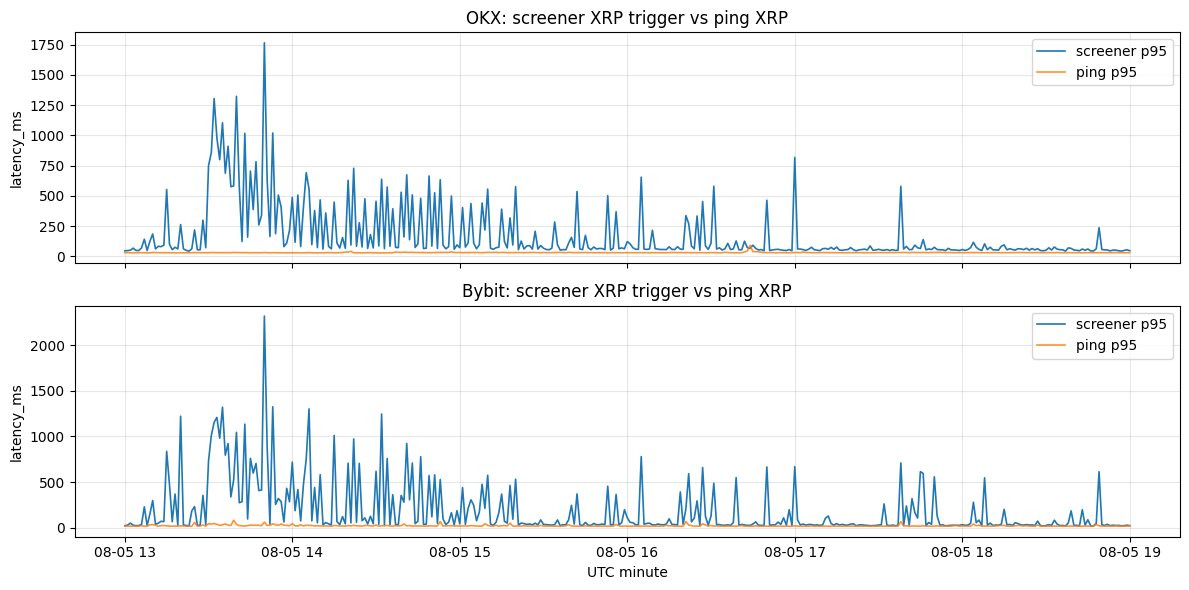

wrote /Users/mishatrubik/Desktop/spread/output/latency_screener_vs_ping_scatter_p95.png


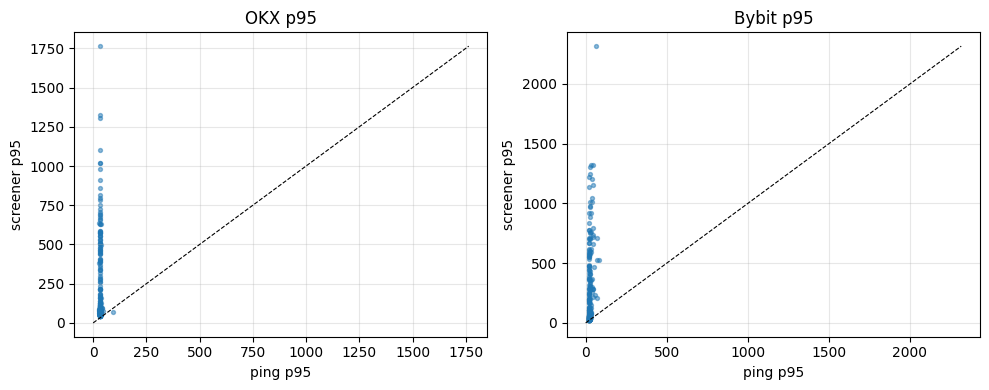

wrote /Users/mishatrubik/Desktop/spread/output/latency_screener_vs_ping_ecdf.png


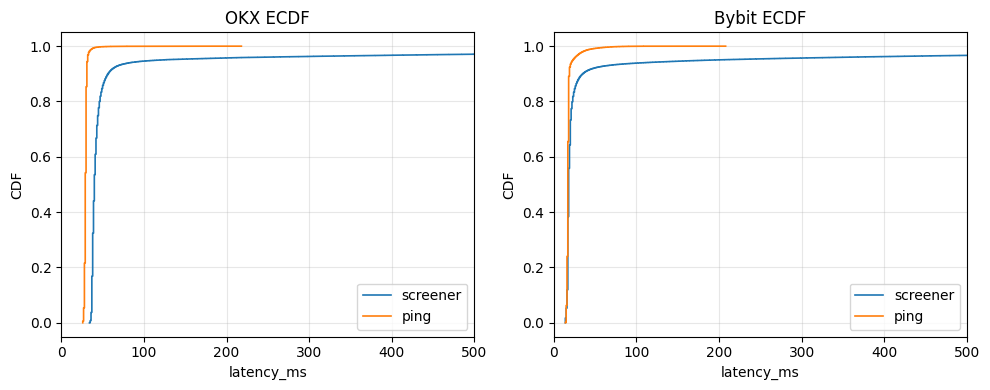

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, m, title in (
    (axes[0], m_okx, "OKX: screener XRP trigger vs ping XRP"),
    (axes[1], m_bybit, "Bybit: screener XRP trigger vs ping XRP"),
):
    if not m.empty:
        ax.plot(m["minute"], m["S_p95"], label="screener p95", lw=1.2)
        ax.plot(m["minute"], m["P_p95"], label="ping p95", lw=1.2, alpha=0.85)
    ax.set_ylabel("latency_ms")
    ax.set_title(title)
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("UTC minute")
plt.tight_layout()
p1 = OUT_DIR / "latency_screener_vs_ping_timeseries_p95.png"
fig.savefig(p1, dpi=140)
print("wrote", p1)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, m, title in ((axes[0], m_okx, "OKX p95"), (axes[1], m_bybit, "Bybit p95")):
    sub = m.dropna(subset=["S_p95", "P_p95"])
    if not sub.empty:
        ax.scatter(sub["P_p95"], sub["S_p95"], s=8, alpha=0.5)
        lim = max(sub["P_p95"].max(), sub["S_p95"].max())
        ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_xlabel("ping p95")
    ax.set_ylabel("screener p95")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
p2 = OUT_DIR / "latency_screener_vs_ping_scatter_p95.png"
fig.savefig(p2, dpi=140)
print("wrote", p2)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, s_series, p_series, title in (
    (axes[0], s_okx.get("trigger_latency_ms", pd.Series(dtype=float)), p_okx.get("latency_ms", pd.Series(dtype=float)), "OKX ECDF"),
    (axes[1], s_bybit.get("trigger_latency_ms", pd.Series(dtype=float)), p_bybit_metric.get("metric_ms", pd.Series(dtype=float)), "Bybit ECDF"),
):
    for series, label in ((s_series, "screener"), (p_series, "ping")):
        v = pd.to_numeric(series, errors="coerce").dropna().sort_values()
        if v.empty:
            continue
        y = (pd.Series(range(1, len(v) + 1)) / len(v)).to_numpy()
        ax.plot(v.to_numpy(), y, label=label, lw=1.2)
    ax.set_xlabel("latency_ms")
    ax.set_ylabel("CDF")
    ax.set_title(title)
    ax.set_xlim(0, 500)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
p3 = OUT_DIR / "latency_screener_vs_ping_ecdf.png"
fig.savefig(p3, dpi=140)
print("wrote", p3)
plt.show()

## 5. Dual-spike count (both legs high on same screener row)

На одной строке оба `*_latency_ms` — снимки последних доставок. Одновременный dual-spike при тихом ping → кандидат на loop/I/O/clock (исход B/E).

dual-spike minutes (both legs > 500 ms): 171 / 361; quiet ping both < thr: 171
                   minute  bybit  okx
2026-08-05 13:02:00+00:00   25.0 34.0
2026-08-05 13:03:00+00:00   35.0 33.0
2026-08-05 13:06:00+00:00   65.0 48.0
2026-08-05 13:07:00+00:00   59.0 38.0
2026-08-05 13:08:00+00:00   51.0 37.0
2026-08-05 13:09:00+00:00  102.0 39.0
2026-08-05 13:10:00+00:00  114.0 56.0
2026-08-05 13:11:00+00:00   59.0 37.0
2026-08-05 13:13:00+00:00   87.0 40.0
2026-08-05 13:15:00+00:00   35.0 42.0
2026-08-05 13:19:00+00:00   36.0 48.0
2026-08-05 13:20:00+00:00  110.0 56.0
2026-08-05 13:24:00+00:00   35.0 40.0
2026-08-05 13:25:00+00:00   80.0 45.0
2026-08-05 13:27:00+00:00  106.0 35.0
2026-08-05 13:30:00+00:00   80.0 37.0
2026-08-05 13:31:00+00:00  132.0 57.0
2026-08-05 13:32:00+00:00   99.0 60.0
2026-08-05 13:33:00+00:00  129.0 37.0
2026-08-05 13:34:00+00:00   61.0 39.0
dual-spike minutes (both legs > 1000 ms): 42 / 361; quiet ping both < thr: 42
                   minute  bybit  okx
2026-08

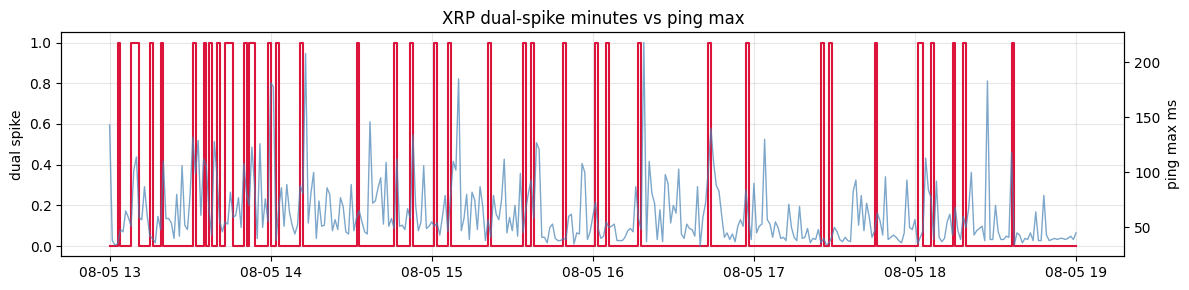

,thr_ms,dual_minutes,total_minutes,quiet_ping_minutes
0,500,171,361,171
1,1000,42,361,42


In [7]:
def dual_spike_minutes(df: pd.DataFrame, thr: float) -> pd.Series:
    if df is None or df.empty:
        return pd.Series(dtype=bool)
    hit = (df["okx_latency_ms"] > thr) & (df["bybit_latency_ms"] > thr)
    return df.loc[hit].groupby("minute").size().reindex(
        df["minute"].unique(), fill_value=0
    ) > 0


probe = df_xrp_win
dual_rows = []
for thr in (SPIKE_MS, DUAL_SPIKE_MS):
    flags = dual_spike_minutes(probe, thr)
    n_min = int(flags.sum()) if len(flags) else 0
    quiet_n = 0
    joined = pd.DataFrame()
    if n_min and not df_ping.empty:
        ping_max = clip(df_ping, t0, t1).groupby(["minute", "exchange"])["latency_ms"].max().unstack()
        joined = flags[flags].index.to_frame(index=False).merge(ping_max.reset_index(), on="minute", how="left")
        if "okx" in joined.columns and "bybit" in joined.columns:
            quiet_mask = (joined["okx"].fillna(0) < thr) & (joined["bybit"].fillna(0) < thr)
            quiet_n = int(quiet_mask.sum())
    print(f"dual-spike minutes (both legs > {thr} ms): {n_min} / {len(flags)}; quiet ping both < thr: {quiet_n}")
    dual_rows.append({"thr_ms": thr, "dual_minutes": n_min, "total_minutes": int(len(flags)), "quiet_ping_minutes": quiet_n})
    if n_min:
        print(joined.head(20).to_string(index=False))

dual_tbl = pd.DataFrame(dual_rows)
dual_path = OUT_DIR / "latency_screener_vs_ping_dual_spike.csv"
dual_tbl.to_csv(dual_path, index=False)
print("wrote", dual_path)

# heatstrip: dual >1000 + ping max overlay
flags_1k = dual_spike_minutes(probe, DUAL_SPIKE_MS)
if len(flags_1k):
    ping_max_min = clip(df_ping, t0, t1).groupby("minute")["latency_ms"].max()
    fig, ax = plt.subplots(figsize=(12, 3))
    minutes = pd.Series(sorted(probe["minute"].unique()))
    y = minutes.map(lambda m: 1 if bool(flags_1k.get(m, False)) else 0)
    ax.step(minutes, y, where="post", label=f"dual>{DUAL_SPIKE_MS}", color="crimson")
    ax2 = ax.twinx()
    ax2.plot(ping_max_min.index, ping_max_min.values, color="steelblue", alpha=0.7, lw=1, label="ping max")
    ax.set_ylabel("dual spike")
    ax2.set_ylabel("ping max ms")
    ax.set_title("XRP dual-spike minutes vs ping max")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    p4 = OUT_DIR / "latency_screener_vs_ping_dual_heatstrip.png"
    fig.savefig(p4, dpi=140)
    print("wrote", p4)
    plt.show()

dual_tbl

## 6. Interpretation checklist (A–E)

In [8]:
def _row(df: pd.DataFrame, name: str) -> pd.Series:
    hit = df.loc[df["series"].eq(name)]
    return hit.iloc[0] if len(hit) else pd.Series(dtype=float)


s_okx_q = _row(summary, "S_okx XRP trigger")
p_okx_q = _row(summary, "P_okx ping")
s_bb_q = _row(summary, "S_bybit XRP trigger")
p_bb_q = _row(summary, "P_bybit ping age_ts")
fresh_okx = _row(summary, "S_okx freshness")
fresh_bb = _row(summary, "S_bybit freshness")

neg_frac = float((df_xrp_win["trigger_latency_ms"] < 0).mean()) if not df_xrp_win.empty else 0.0
d_okx = delta_tbl.loc[delta_tbl["leg"].eq("OKX")].iloc[0] if len(delta_tbl) else {}
d_bb = delta_tbl.loc[delta_tbl["leg"].eq("Bybit")].iloc[0] if len(delta_tbl) else {}
dual_1k = dual_tbl.loc[dual_tbl["thr_ms"].eq(DUAL_SPIKE_MS)].iloc[0] if len(dual_tbl) else {}

checks = {
    "A_S_approx_P_p50_p95": (
        abs(float(s_okx_q.get("p50", 0)) - float(p_okx_q.get("p50", 0))) < 20
        and abs(float(s_okx_q.get("p95", 0)) - float(p_okx_q.get("p95", 0))) < 40
        and abs(float(s_bb_q.get("p50", 0)) - float(p_bb_q.get("p50", 0))) < 20
        and abs(float(s_bb_q.get("p95", 0)) - float(p_bb_q.get("p95", 0))) < 40
    ),
    "B_heavier_tail_plus_quiet_dual": (
        float(s_okx_q.get("p99", 0)) > float(p_okx_q.get("p99", 0)) + 100
        or float(s_bb_q.get("p99", 0)) > float(p_bb_q.get("p99", 0)) + 100
    )
    and int(dual_1k.get("quiet_ping_minutes", 0)) > 0,
    "C_systematic_p50_uplift": (
        float(d_okx.get("median_d_p50", 0)) > 30 or float(d_bb.get("median_d_p50", 0)) > 30
    ),
    "D_bybit_shared_spikes_dual_unexplained": (
        float(s_bb_q.get("p99", 0)) > 200
        and float(p_bb_q.get("p99", 0)) > 100
        and int(dual_1k.get("quiet_ping_minutes", 0)) > 0
    ),
    # Tiny freshness + heavy S tail with quiet ping is B, not E.
    "E_clock_or_def_mismatch": neg_frac > 0.001,
}

# provisional primary label
if checks["A_S_approx_P_p50_p95"] and not checks["B_heavier_tail_plus_quiet_dual"] and not checks["C_systematic_p50_uplift"]:
    primary = "A"
elif checks["C_systematic_p50_uplift"] and not checks["B_heavier_tail_plus_quiet_dual"]:
    primary = "C"
elif checks["B_heavier_tail_plus_quiet_dual"] and checks["D_bybit_shared_spikes_dual_unexplained"]:
    primary = "D+B"
elif checks["B_heavier_tail_plus_quiet_dual"]:
    primary = "B"
elif checks["D_bybit_shared_spikes_dual_unexplained"]:
    primary = "D"
elif checks["E_clock_or_def_mismatch"]:
    primary = "E"
else:
    primary = "mixed"

verdict = {
    "primary_label": primary,
    "overlap_t0": str(t0),
    "overlap_t1": str(t1),
    "neg_latency_frac": neg_frac,
    **{k: bool(v) for k, v in checks.items()},
    "S_okx_p50": float(s_okx_q.get("p50", float("nan"))),
    "P_okx_p50": float(p_okx_q.get("p50", float("nan"))),
    "S_okx_p95": float(s_okx_q.get("p95", float("nan"))),
    "P_okx_p95": float(p_okx_q.get("p95", float("nan"))),
    "S_okx_p99": float(s_okx_q.get("p99", float("nan"))),
    "P_okx_p99": float(p_okx_q.get("p99", float("nan"))),
    "S_bybit_p50": float(s_bb_q.get("p50", float("nan"))),
    "P_bybit_p50": float(p_bb_q.get("p50", float("nan"))),
    "S_bybit_p95": float(s_bb_q.get("p95", float("nan"))),
    "P_bybit_p95": float(p_bb_q.get("p95", float("nan"))),
    "S_bybit_p99": float(s_bb_q.get("p99", float("nan"))),
    "P_bybit_p99": float(p_bb_q.get("p99", float("nan"))),
    "fresh_okx_p95": float(fresh_okx.get("p95", float("nan"))),
    "fresh_bybit_p95": float(fresh_bb.get("p95", float("nan"))),
    "dual_1k_minutes": int(dual_1k.get("dual_minutes", 0)),
    "dual_1k_quiet_ping": int(dual_1k.get("quiet_ping_minutes", 0)),
}
verdict_df = pd.DataFrame([verdict])
verdict_path = OUT_DIR / "latency_screener_vs_ping_verdict.csv"
verdict_df.to_csv(verdict_path, index=False)
print("PRIMARY VERDICT:", primary)
print("checks:", checks)
print("wrote", verdict_path)
verdict_df.T

PRIMARY VERDICT: B
checks: {'A_S_approx_P_p50_p95': False, 'B_heavier_tail_plus_quiet_dual': True, 'C_systematic_p50_uplift': False, 'D_bybit_shared_spikes_dual_unexplained': False, 'E_clock_or_def_mismatch': False}
wrote /Users/mishatrubik/Desktop/spread/output/latency_screener_vs_ping_verdict.csv


,0
primary_label,B
overlap_t0,2026-08-05 13:00:27.674000+00:00
overlap_t1,2026-08-05 19:00:27.335000+00:00
neg_latency_frac,0.0
A_S_approx_P_p50_p95,False
B_heavier_tail_plus_quiet_dual,True
C_systematic_p50_uplift,False
D_bybit_shared_spikes_dual_unexplained,False
E_clock_or_def_mismatch,False
S_okx_p50,40.0
